# Palace Straight Dielectric Waveguide - Wave Ports

This notebook sets up a straight dielectric waveguide and runs a Palace driven simulation using waveport boundary conditions.

### Build straight waveguide geometry

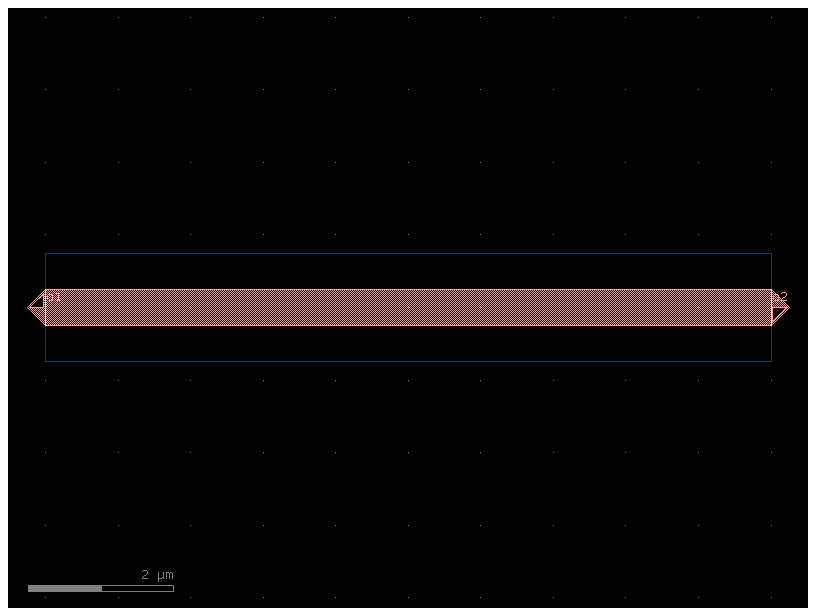

In [1]:
from ubcpdk import PDK, cells

PDK.activate()

c = cells.straight(length=10.0)

cc = c.copy()
cc.draw_ports()
cc

### Configure Palace driven simulation

In [2]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-straight-waveport")
sim.set_geometry(c)

sim.set_stack(
    substrate_thickness=2.0,
    add_oxide_dielectric=False,
    add_passivation_dielectric=False,
)

sim.set_numerical(
    solver_type="MUMPS",
    max_iterations=1,
    tolerance=1e-8,
)

for i, port in enumerate(c.ports):
    sim.add_wave_port(
        str(port.name),
        layer="core",
        z_margin=1.5,
        lateral_margin=1.5,
        max_size=False,
        mode=1,
        excited=(i == 0),
    )

sim.set_driven(fmin=190e12, fmax=200e12, num_points=21)

print(sim.validate_config())

Validation: PASSED


### Generate mesh

In [3]:
sim.set_airbox(
    margin_x=0.0,
    margin_y=2.0,
    z_above=0.5,
    z_below=0.5,
)

sim.mesh(
    preset="fine",
    refined_mesh_size=0.04,
    max_mesh_size=0.2,
    fmax=200e12,
)

Mesh Summary
Dimensions: 10.0 x 8.5 x 6.5 µm
Nodes:      64,672
Elements:   391,482
Tetrahedra: 350,342
Edge length: 0.03 - 0.44 µm
Quality:    0.771 (min: 0.207)
SICN:       0.798 (all valid)
----------------------------------------
Volumes (2):
  - core [1]
  - air [2]
Surfaces (4):
  - P1 [3]
  - P2 [4]
  - air__core [5]
  - air__None [6]
----------------------------------------
Mesh:   palace-sim-straight-waveport/palace.msh

In [4]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:35709/index.html?ui=P_0x7a0b66b2d340_0&reconnect=auto" class="pyvi…

### Run simulation

In [ ]:
import json
from pathlib import Path

config_path = sim.write_config(photonic=True)
cfg = json.loads(Path(config_path).read_text())
print("Solver.Linear:", cfg["Solver"]["Linear"])

results = sim.run_local(num_processes=4, verbose=True)

### Plot S-parameters

In [ ]:
results.plot_interactive()

In [ ]:
results.plot_interactive(phase=True)